# The production adjoint: stability over five years, and whether its pathways stay meaningful

Run 31206: the 5-yr approximate adjoint of the production configuration (scheme 33 with explicit vertical advection in the forward sweep, scheme 30 in the adjoint sweep through `useApproxAdvectionInAdMode` and the `approxAdv` build; reference viscosity + `viscAhReMax=2.`, GM off), started from the year-180 pickup of the reference leg 31205 (10 yr under the same forward configuration from the 2× spin-up's year-170 state). Cost: the terminal-30-day mean Atlantic heat transport across the 26° N section.

Comparison run 31171: the **exact** adjoint of a smooth model, scheme 30 in both sweeps, on a different trajectory (the 2× spin-up's year-180 pickup, implicit vertical advection), same cost, same 5-yr window. The two share no code path for the tracer advection and not the same forward state, so agreement between them is evidence that the sensitivity pathways are properties of the physics, not of the linearisation.

Diagnostics: rms and maximum of the `ADJ*` dumps against lead (5-d dumps over 1830 d); the lead-by-lead spatial correlation of `ADJtheta` between the two runs; sensitivity maps and sections at 30 d, 1, 2, 3, 4, 5 yr of lead; the centroid and the regional shares of |dJ/dθ| against lead. Figures to `analysis/kappa_v_ensemble_ReMax2_approxAdv/figures/` on scratch.

In [1]:
import os, glob, warnings
import numpy as np, xmitgcm
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
warnings.filterwarnings('ignore')
SCRATCH = '/scratch2/tshahriar/DINO_1deg_outputs'; A = SCRATCH + '/runs/adjoint'
FIG_DIR = SCRATCH + '/analysis/kappa_v_ensemble_ReMax2_approxAdv/figures'; os.makedirs(FIG_DIR, exist_ok=True)
def find(job):
    hits = glob.glob(f'{A}/*run{job}') + glob.glob(f'{A}/*/*run{job}'); assert hits, job; return hits[0]
RUNS = {'approximate, production (31206)': find(31206), 'exact scheme 30, 2x pickup (31171)': find(31171)}
SPD = 48
def par(d, name):
    return int([l for l in open(d + '/data') if name in l and not l.strip().startswith('#')][0].split('=')[1].strip(' ,\n'))
def dumps(d, var):
    fs = sorted(glob.glob(f'{d}/{var}.*.data')); its = np.array([int(os.path.basename(f).split('.')[1]) for f in fs])
    return fs, (par(d, 'nIter0') + par(d, 'nTimeSteps') - its) / SPD
def rd(f): return np.fromfile(f, dtype='>f4').astype('f8')

== approximate, production (31206): fc 3.35016470827443E-01; 366 dumps, lead 5..1830 d, all finite True
     lead    30 d: rms 3.958e-04  max 3.469e-02
     lead   180 d: rms 1.457e-04  max 1.305e-02
     lead   365 d: rms 9.337e-05  max 4.688e-03
     lead   730 d: rms 6.757e-05  max 1.273e-03
     lead  1095 d: rms 7.105e-05  max 2.030e-03
     lead  1460 d: rms 6.360e-05  max 1.811e-03
     lead  1825 d: rms 4.805e-05  max 1.195e-03


== exact scheme 30, 2x pickup (31171): fc 2.43406049027578E-01; 366 dumps, lead 5..1830 d, all finite True
     lead    30 d: rms 4.197e-04  max 3.759e-02
     lead   180 d: rms 1.565e-04  max 1.238e-02
     lead   365 d: rms 1.004e-04  max 5.214e-03
     lead   730 d: rms 6.791e-05  max 1.192e-03
     lead  1095 d: rms 6.845e-05  max 1.677e-03
     lead  1460 d: rms 6.389e-05  max 1.752e-03
     lead  1825 d: rms 5.006e-05  max 1.198e-03


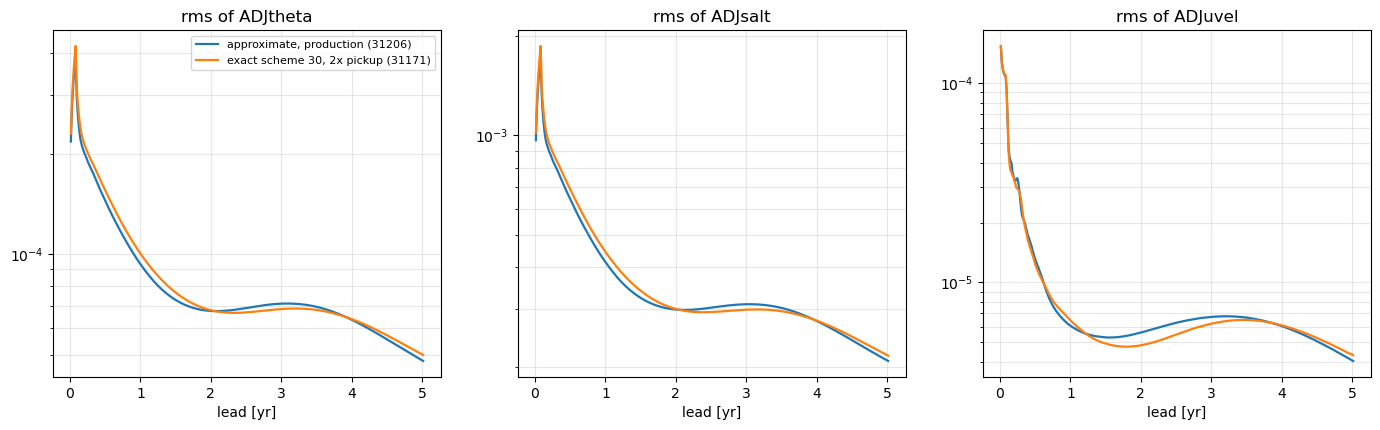

In [2]:
stats = {}
for lab, d in RUNS.items():
    fc = [l.split('=')[-1].strip() for l in open(d + '/STDOUT.0000') if 'global fc' in l][0]
    stats[lab] = {'fc': fc}
    for var in ('ADJtheta', 'ADJsalt', 'ADJuvel', 'ADJdiffkr'):
        fs, lead = dumps(d, var)
        if not fs: continue
        rms = np.array([np.sqrt(np.mean(rd(f)**2)) for f in fs]); mx = np.array([np.abs(rd(f)).max() for f in fs])
        o = np.argsort(lead); stats[lab][var] = (lead[o], rms[o], mx[o], all(np.isfinite(rd(f)).all() for f in fs))
    l, r, m, fin = stats[lab]['ADJtheta']
    print(f"== {lab}: fc {fc}; {len(l)} dumps, lead {l.min():.0f}..{l.max():.0f} d, all finite {fin}")
    for L in (30, 180, 365, 730, 1095, 1460, 1825):
        k = np.argmin(np.abs(l - L)); print(f"     lead {l[k]:5.0f} d: rms {r[k]:.3e}  max {m[k]:.3e}")
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
for i, var in enumerate(('ADJtheta', 'ADJsalt', 'ADJuvel')):
    for lab in RUNS:
        l, r, m, fin = stats[lab][var]; ax[i].semilogy(l / 365.25, r, lw=1.6, label=lab)
    ax[i].set_title(f'rms of {var}'); ax[i].set_xlabel('lead [yr]'); ax[i].grid(alpha=0.3, which='both')
ax[0].legend(fontsize=8); fig.savefig(f'{FIG_DIR}/adjoint_growth_31206_vs_31171.png', dpi=110, bbox_inches='tight')

lead [d] : correlation, rms ratio (approximate / exact scheme 30)
      5 : 0.992  0.95
    155 : 0.958  0.93
    305 : 0.936  0.93
    455 : 0.938  0.93
    605 : 0.939  0.96
    755 : 0.930  1.00
    905 : 0.920  1.03
   1055 : 0.915  1.04
   1205 : 0.912  1.03
   1355 : 0.910  1.01
   1505 : 0.910  0.99
   1655 : 0.913  0.97
   1805 : 0.918  0.96


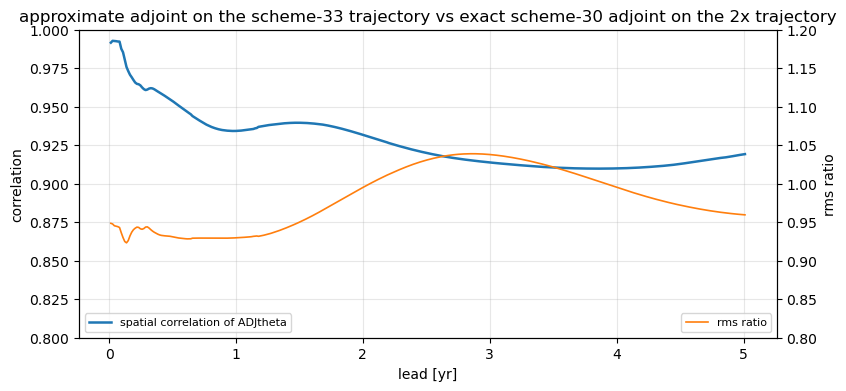

In [3]:
# lead-by-lead spatial correlation of ADJtheta between the two runs
(d0, d1) = RUNS.values(); fs0, lead0 = dumps(d0, 'ADJtheta'); fs1, lead1 = dumps(d1, 'ADJtheta')
rows = []
for f0, L in zip(fs0, lead0):
    k = np.where(lead1 == L)[0]
    if not len(k): continue
    a, b = rd(f0), rd(fs1[k[0]]); mm = (a != 0) | (b != 0)
    rows.append((L, np.corrcoef(a[mm], b[mm])[0, 1], np.sqrt(np.mean(a**2)) / np.sqrt(np.mean(b**2))))
rows = np.array(sorted(rows)); np.savetxt(f'{FIG_DIR}/adjtheta_corr_31206_vs_31171.txt', rows, header='lead_d corr rms_ratio')
print('lead [d] : correlation, rms ratio (approximate / exact scheme 30)')
for L, cc, q in rows[::30]: print(f'  {L:5.0f} : {cc:.3f}  {q:.2f}')
fig, ax = plt.subplots(figsize=(9, 4)); ax.plot(rows[:, 0] / 365.25, rows[:, 1], lw=1.8, label='spatial correlation of ADJtheta'); ax.set_ylim(0.8, 1.0)
ax2 = ax.twinx(); ax2.plot(rows[:, 0] / 365.25, rows[:, 2], 'C1', lw=1.2, label='rms ratio'); ax2.set_ylim(0.8, 1.2)
ax.set_xlabel('lead [yr]'); ax.set_ylabel('correlation'); ax2.set_ylabel('rms ratio'); ax.grid(alpha=0.3); ax.set_title('approximate adjoint on the scheme-33 trajectory vs exact scheme-30 adjoint on the 2x trajectory')
ax.legend(loc='lower left', fontsize=8); ax2.legend(loc='lower right', fontsize=8); fig.savefig(f'{FIG_DIR}/adjtheta_corr_31206_vs_31171.png', dpi=110, bbox_inches='tight')

approximate_production_31206:  lead  centroid_lat  centroid_depth  share_south(<-45)  share_tropics(|lat|<15)  share_north(>30)
    1830          13.0           -1639               0.03                     0.14              0.37
    1680          11.8           -1634               0.03                     0.15              0.35
    1530          11.0           -1629               0.03                     0.15              0.33
    1380          10.6           -1627               0.03                     0.16              0.32
    1230          10.7           -1631               0.03                     0.17              0.31
    1080          11.4           -1641               0.03                     0.20              0.31
     930          12.5           -1656               0.02                     0.22              0.32
     780          13.9           -1674               0.02                     0.24              0.34
     630          15.5           -1693               0.02       

exact_scheme_30_2x_pickup_31171:  lead  centroid_lat  centroid_depth  share_south(<-45)  share_tropics(|lat|<15)  share_north(>30)
    1830          10.4           -1644               0.05                     0.14              0.36
    1680           9.6           -1640               0.05                     0.14              0.34
    1530           9.2           -1640               0.04                     0.15              0.32
    1380           9.2           -1642               0.04                     0.15              0.31
    1230           9.8           -1648               0.04                     0.16              0.31
    1080          10.8           -1657               0.03                     0.18              0.31
     930          12.2           -1670               0.03                     0.20              0.33
     780          13.9           -1684               0.03                     0.22              0.34
     630          15.6           -1697               0.02    

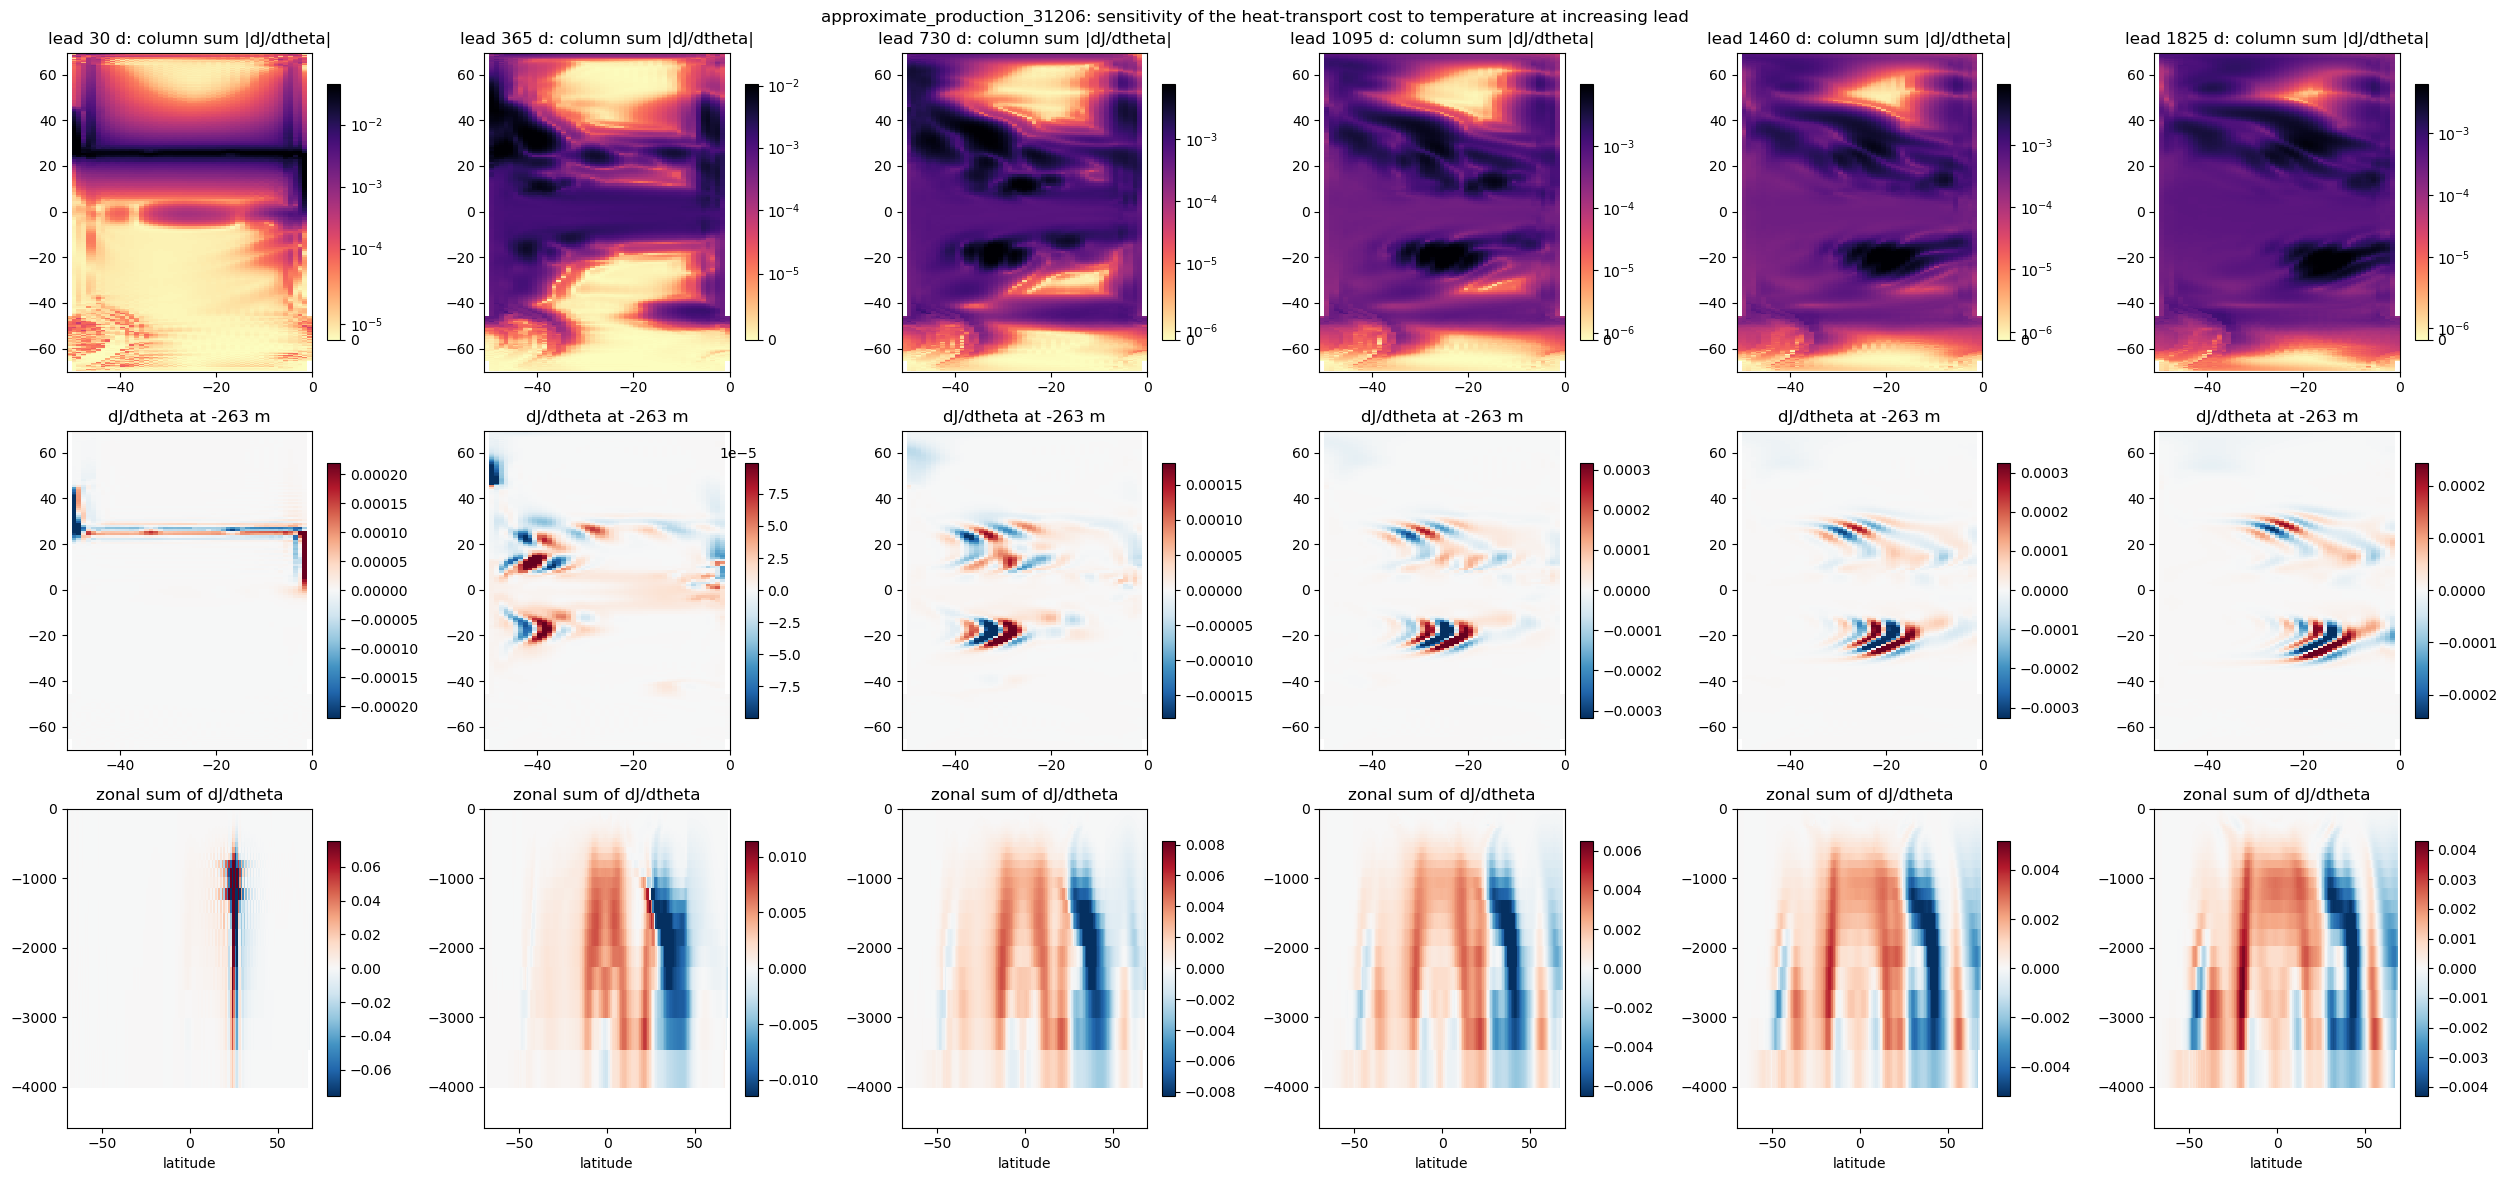

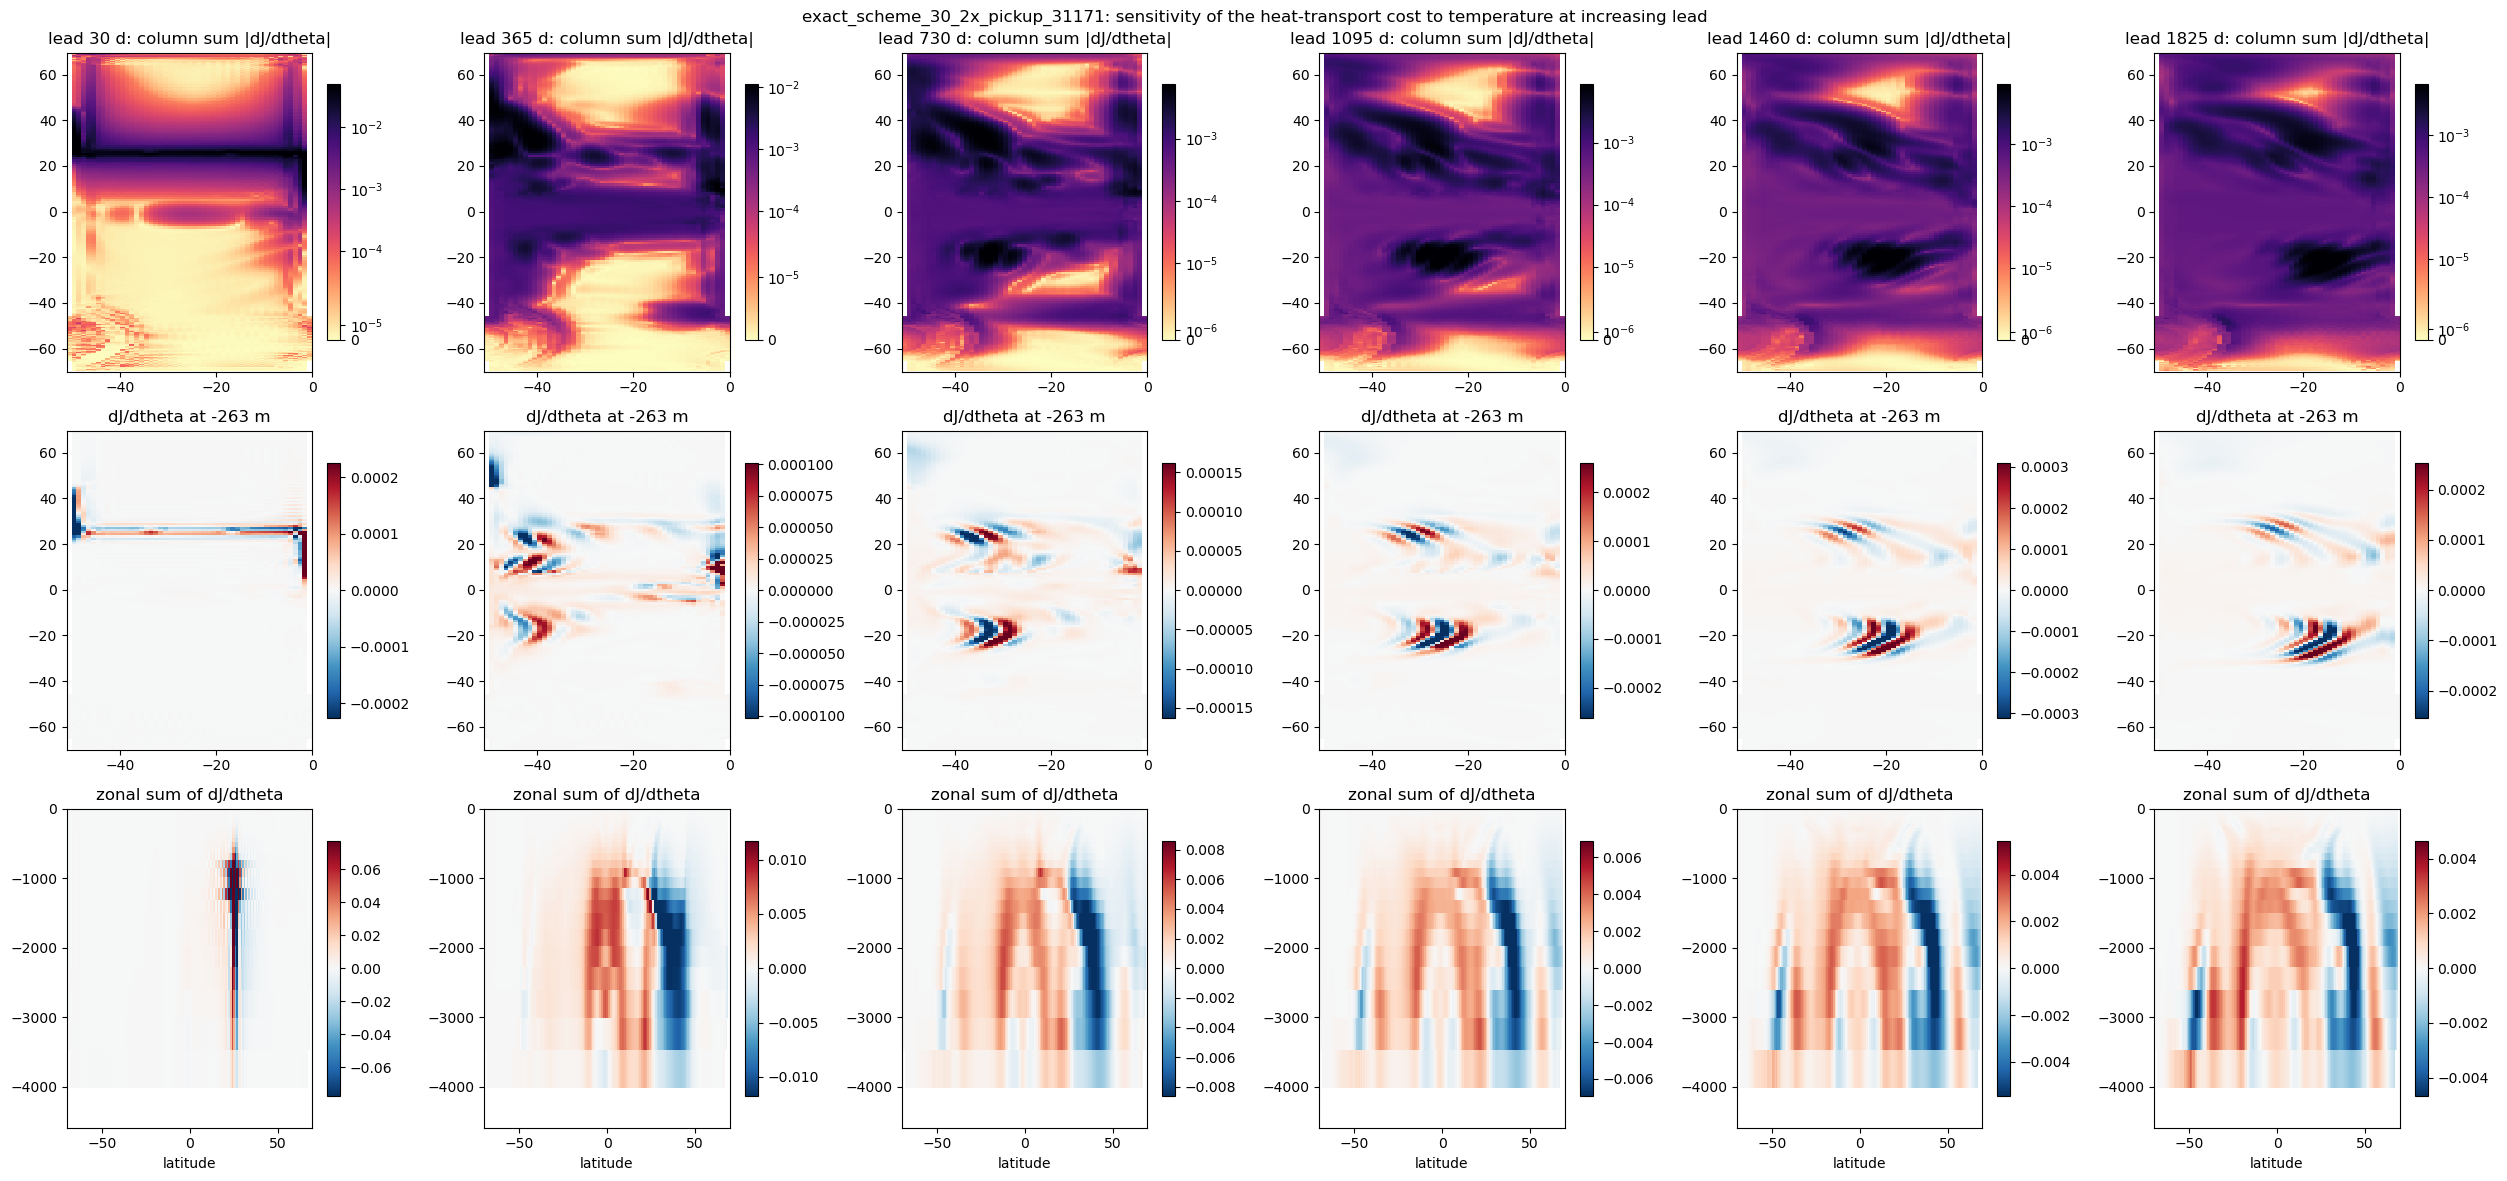

In [4]:
def sens_maps(lab, d, leads=(30, 365, 730, 1095, 1460, 1825)):
    g = xmitgcm.open_mdsdataset(d, grid_dir=d, prefix=[], iters=None, read_grid=True, geometry='curvilinear')
    XC, YC, Z, hFacC = g.XC.values, g.YC.values, g.Z.values, g.hFacC.values
    fs, lead = dumps(d, 'ADJtheta'); sel = [(lead[np.argmin(np.abs(lead - L))], fs[np.argmin(np.abs(lead - L))]) for L in leads]
    fig, ax = plt.subplots(3, len(sel), figsize=(4.2 * len(sel), 12), squeeze=False)
    for c_, (L, f) in enumerate(sel):
        Af = rd(f).reshape(36, 198, 51); col = np.nansum(np.abs(Af) * (hFacC > 0), axis=0)
        zm = np.where((hFacC > 0).any(axis=2), np.nansum(Af * (hFacC > 0), axis=2), np.nan)
        vmax = np.nanpercentile(col[col > 0], 99.5)
        im = ax[0, c_].pcolormesh(XC, YC, np.where(col > 0, col, np.nan), norm=SymLogNorm(linthresh=vmax * 1e-3, vmin=0, vmax=vmax), cmap='magma_r', shading='auto'); fig.colorbar(im, ax=ax[0, c_], shrink=0.8)
        ax[0, c_].set_title(f'lead {L:.0f} d: column sum |dJ/dtheta|')
        Ak = Af[15]; v = np.nanpercentile(np.abs(Ak[hFacC[15] > 0]), 99.5)
        im = ax[1, c_].pcolormesh(XC, YC, np.where(hFacC[15] > 0, Ak, np.nan), cmap='RdBu_r', vmin=-v, vmax=v, shading='auto'); fig.colorbar(im, ax=ax[1, c_], shrink=0.8); ax[1, c_].set_title(f'dJ/dtheta at {Z[15]:.0f} m')
        v = np.nanpercentile(np.abs(zm[np.isfinite(zm)]), 99.5)
        im = ax[2, c_].pcolormesh(YC[:, 0], Z, zm, cmap='RdBu_r', vmin=-v, vmax=v, shading='auto'); fig.colorbar(im, ax=ax[2, c_], shrink=0.8); ax[2, c_].set_title('zonal sum of dJ/dtheta'); ax[2, c_].set_xlabel('latitude')
    fig.suptitle(f'{lab}: sensitivity of the heat-transport cost to temperature at increasing lead'); fig.tight_layout()
    fig.savefig(f'{FIG_DIR}/sensitivity_maps_{lab.split()[0]}.png', dpi=100, bbox_inches='tight')
    # regional shares
    print(f'{lab}:  lead  centroid_lat  centroid_depth  share_south(<-45)  share_tropics(|lat|<15)  share_north(>30)')
    lat3 = np.broadcast_to(YC[None], (36, 198, 51)); z3 = np.broadcast_to(Z[:, None, None], (36, 198, 51))
    for k in range(0, len(fs), 30):
        Aa = np.abs(rd(fs[k]).reshape(36, 198, 51)) * (hFacC > 0); w = Aa.sum()
        print(f'   {lead[k]:5.0f}  {np.sum(Aa*lat3)/w:12.1f}  {np.sum(Aa*z3)/w:14.0f}  {Aa[lat3 < -45].sum()/w:17.2f}  {Aa[np.abs(lat3) < 15].sum()/w:23.2f}  {Aa[lat3 > 30].sum()/w:16.2f}')
for lab, d in RUNS.items(): sens_maps(lab.replace(' ', '_').replace(',', '').replace('(', '').replace(')', ''), d)

## Reading

- **Stable over the whole window.** The production adjoint is finite at every one of its 366 dumps and its rms decays monotonically apart from the small seasonal modulation: 2.2e-4 at 5 d of lead, 9e-5 at one year, 5e-5 at five years, with the same numbers to within 7 percent in the exact scheme-30 adjoint. Nothing in it resembles the 1 to 3-day bursts that the limiter's adjoint produced.
- **The pathways are the same as an exact adjoint's.** The spatial correlation of the temperature sensitivity between the approximate adjoint (scheme-33 trajectory, reference viscosity) and the exact scheme-30 adjoint (2× trajectory) is 0.99 at one month, 0.95 at six months and stays between 0.91 and 0.94 from one to five years of lead; the rms ratio stays within 0.93 to 1.04. The centroid of |dJ/dθ| moves from the section at 26° N to 11 to 13° N by year 3 to 5 and from 1.5 km to 1.6 km depth in both, the tropical share rises to a third within four months and falls back to 15 percent, the channel share grows slowly to 3 to 5 percent. Two adjoints that share neither the tracer discretisation nor the forward state agree on where the sensitivity lives at every lead; that is the case for the pathways being physical.
- **What the pathways are.** At one month the sensitivity is on the cost section and the western boundary. By one year it has organised into westward-propagating Rossby-wave chevrons in both subtropical gyres at thermocline depth, a deep dipole around the section that spreads equatorward along the basin, and a weak signal along the eastern boundary; by three to five years the chevrons have reached the western boundary, the deep signal fills the tropical and southern basin below 1 km, and the channel appears.